# T9 – Singh med korrigerad shuntsusceptans och diagnostik

Denna notebook är en komplett T9-version. Den läser in data radvis, kör Singh-metoden med korrigerad hantering av shuntsusceptansen \(jB\), jämför mot tidigare B-hantering och genomför diagnostik för fasmappning, strömriktning och vinkeloffsetar.

In [1]:

# ============================================================
# T9_Singh_corrected_B_diagnostics
# Komplett notebook för:
#   1) rowwise inläsning av send/rec-data
#   2) korrigerad Singh-implementation med shuntsusceptans jB
#   3) jämförelse mot tidigare B-hantering
#   4) diagnostik av fasmappning, strömriktning och vinkeloffsetar
# ============================================================

import os
from pathlib import Path
import itertools

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.options.mode.chained_assignment = None

# ============================================================
# ÄNDRA ENDAST DESSA FILVÄGAR VID BEHOV
# ============================================================

send_file = r"C:\Users\lundi\OneDrive\Skóli\Svíþjóð\Exjobb\Arbetet\Källor\phasor_dlr-main\phasor_dlr-main\data\send-station.xlsx"
rec_file  = r"C:\Users\lundi\OneDrive\Skóli\Svíþjóð\Exjobb\Arbetet\Källor\phasor_dlr-main\phasor_dlr-main\data\rec-station.xlsx"

keyS_sheet  = "K-nyckel"
dataS_sheet = "Station_K_3x15000"

keyR_sheet  = "F-nyckel"
dataR_sheet = "Station_F_3x15000"

OUTPUT_DIR = Path(r"C:\Users\lundi\OneDrive\Skóli\Svíþjóð\Exjobb\Arbetet\Källor\phasor_dlr-main\phasor_dlr-main\data\T9_Singh_corrected_B_diagnostics")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Referenser
PHASES = ["L1", "L2", "L3"]
R_REF = 1.2575       # Ohm, ändra endast om du aktivt använder annan referens
X_REF = 6.555        # Ohm, referensreaktans för diagnostik
ALPHA = 0.00403      # 1/°C, aluminium

WINDOW_SECONDS = 120
STEP_SECONDS = 5
QUICK_WINDOWS = 2    # används i snabba diagnostester

print("send finns:", os.path.exists(send_file))
print("rec finns :", os.path.exists(rec_file))
print("Output-mapp:", OUTPUT_DIR)


send finns: True
rec finns : True
Output-mapp: C:\Users\lundi\OneDrive\Skóli\Svíþjóð\Exjobb\Arbetet\Källor\phasor_dlr-main\phasor_dlr-main\data\T9_Singh_corrected_B_diagnostics


In [2]:

# ============================================================
# HJÄLPFUNKTIONER FÖR DATA
# ============================================================

def read_key_table_safe(filename, sheetname):
    T = pd.read_excel(filename, sheet_name=sheetname, header=None)
    T = T.iloc[:, :2].copy()
    T.columns = ["Parameter", "ID"]
    T = T.dropna()
    T["Parameter"] = T["Parameter"].astype(str).str.strip()
    T["ID"] = T["ID"].astype(str).str.strip()
    return T

def to_numeric_series(s):
    return pd.to_numeric(
        s.astype(str).str.strip().str.replace(",", ".", regex=False),
        errors="coerce"
    )

def parse_timestamp(s):
    # Data i dina filer verkar ha format med mikrosekunder.
    # Om något enstaka värde inte matchar blir det NaT och filtreras bort.
    return pd.to_datetime(
        s,
        format="%Y-%m-%d %H:%M:%S.%f",
        errors="coerce"
    )

# ============================================================
# LÄS NYCKLAR OCH RÅDATA
# ============================================================

keyS = read_key_table_safe(send_file, keyS_sheet)
keyR = read_key_table_safe(rec_file, keyR_sheet)

mapS = dict(zip(keyS["ID"], keyS["Parameter"]))
mapR = dict(zip(keyR["ID"], keyR["Parameter"]))

send_raw = pd.read_excel(send_file, sheet_name=dataS_sheet, header=None).iloc[:, :3].copy()
rec_raw  = pd.read_excel(rec_file,  sheet_name=dataR_sheet, header=None).iloc[:, :3].copy()

send_raw.columns = ["Timestamp", "ID", "Value"]
rec_raw.columns  = ["Timestamp", "ID", "Value"]

for D in [send_raw, rec_raw]:
    D["ID"] = D["ID"].astype(str).str.strip()
    D["Timestamp"] = parse_timestamp(D["Timestamp"])
    D["Value"] = to_numeric_series(D["Value"])

send_raw = send_raw.dropna(subset=["Timestamp", "ID", "Value"]).copy()
rec_raw  = rec_raw.dropna(subset=["Timestamp", "ID", "Value"]).copy()

send_raw["Parameter"] = send_raw["ID"].map(mapS)
rec_raw["Parameter"]  = rec_raw["ID"].map(mapR)

send_raw = send_raw.dropna(subset=["Parameter"]).copy()
rec_raw  = rec_raw.dropna(subset=["Parameter"]).copy()

send_raw["Parameter"] = send_raw["Parameter"].astype(str).str.strip()
rec_raw["Parameter"]  = rec_raw["Parameter"].astype(str).str.strip()

print("\nRådata:")
print("send rader:", len(send_raw))
print("rec  rader:", len(rec_raw))
print("send tidsintervall:", send_raw["Timestamp"].min(), "->", send_raw["Timestamp"].max())
print("rec  tidsintervall:", rec_raw["Timestamp"].min(), "->", rec_raw["Timestamp"].max())

# ============================================================
# RADVIS PARNING
# ============================================================

N_raw = min(len(send_raw), len(rec_raw))
send = send_raw.iloc[:N_raw].reset_index(drop=True).copy()
rec  = rec_raw.iloc[:N_raw].reset_index(drop=True).copy()

row_pair = pd.DataFrame({
    "row": np.arange(N_raw),
    "Timestamp_S": send["Timestamp"],
    "Timestamp_R": rec["Timestamp"],
    "Parameter_S": send["Parameter"],
    "Parameter_R": rec["Parameter"],
    "Value_S": send["Value"],
    "Value_R": rec["Value"],
})
row_pair["Parameter_match"] = row_pair["Parameter_S"] == row_pair["Parameter_R"]
row_pair["Timestamp_diff_ms"] = (
    row_pair["Timestamp_R"] - row_pair["Timestamp_S"]
).dt.total_seconds() * 1000.0

print("\nRadvis parning:")
print("Parameter mismatch:", int((~row_pair["Parameter_match"]).sum()))
print("Max timestamp-differens [ms]:", row_pair["Timestamp_diff_ms"].abs().max())

if (~row_pair["Parameter_match"]).any():
    print("Exempel på mismatch:")
    display(row_pair.loc[~row_pair["Parameter_match"]].head(20))
    raise ValueError("Radvis parameterordning matchar inte. Kontrollera nyckeltabeller/filer.")

SIGNALS_PER_SAMPLE = row_pair["Parameter_S"].nunique()
print("Unika parametrar:", SIGNALS_PER_SAMPLE)

# Dina filer ska ha 12 signaler per sampel.
# Om detta blir annat än 12 ska du kontrollera nyckeltabellen.
if SIGNALS_PER_SAMPLE != 12:
    print("VARNING: Antal unika parametrar är inte 12.")

row_pair["sample"] = row_pair["row"] // SIGNALS_PER_SAMPLE
row_pair["pos_in_sample"] = row_pair["row"] % SIGNALS_PER_SAMPLE

# Kontrollera att varje sample har samma antal parametrar
sample_counts = row_pair.groupby("sample")["Parameter_S"].nunique()
bad_samples = sample_counts[sample_counts != SIGNALS_PER_SAMPLE]

print("Antal samples:", row_pair["sample"].nunique())
print("Samples med fel antal parametrar:", len(bad_samples))

if len(bad_samples) > 0:
    display(bad_samples.head())
    raise ValueError("Vissa sampel har fel antal parametrar.")

wideS = row_pair.pivot_table(
    index="sample", columns="Parameter_S", values="Value_S", aggfunc="first"
)
wideR = row_pair.pivot_table(
    index="sample", columns="Parameter_R", values="Value_R", aggfunc="first"
)

wideS = wideS.add_suffix("_S")
wideR = wideR.add_suffix("_R")

sample_ts = row_pair.groupby("sample")["Timestamp_S"].first()
sample_dt_ms = row_pair.groupby("sample")["Timestamp_diff_ms"].max()

df_clean = wideS.join(wideR, how="inner").copy()
df_clean["Timestamp"] = sample_ts
df_clean["Max_row_timestamp_diff_ms"] = sample_dt_ms
df_clean = df_clean.set_index("Timestamp").sort_index()

# ============================================================
# RENSNING OCH KONTROLL
# ============================================================

required_cols = []
for ph in PHASES:
    required_cols += [
        f"U{ph}MAG_S", f"U{ph}ANG_S", f"I{ph}MAG_S", f"I{ph}ANG_S",
        f"U{ph}MAG_R", f"U{ph}ANG_R", f"I{ph}MAG_R", f"I{ph}ANG_R",
    ]

missing = [c for c in required_cols if c not in df_clean.columns]
if missing:
    print("Tillgängliga kolumner:")
    print(list(df_clean.columns))
    raise ValueError(f"Saknade kolumner: {missing}")

for c in required_cols:
    df_clean[c] = pd.to_numeric(df_clean[c], errors="coerce")

df_clean = df_clean.dropna(subset=required_cols).copy()

print("\nEfter wide-format och rensning:")
print("Rader:", len(df_clean))
print("Start:", df_clean.index.min())
print("Slut :", df_clean.index.max())
print("Tidslängd:", df_clean.index.max() - df_clean.index.min())

# Spara datakontroll
row_pair.to_excel(OUTPUT_DIR / "rowwise_pairing_check_long.xlsx", index=False)
df_clean.reset_index().to_excel(OUTPUT_DIR / "df_clean_rowwise.xlsx", index=False)

print("Datakontroll sparad.")



Rådata:
send rader: 180000
rec  rader: 180000
send tidsintervall: 2025-12-11 15:25:02.469999 -> 2025-12-11 15:27:32.460000
rec  tidsintervall: 2025-12-11 15:25:02.469999 -> 2025-12-11 15:27:32.459999

Radvis parning:
Parameter mismatch: 0
Max timestamp-differens [ms]: 0.002
Unika parametrar: 12
Antal samples: 15000
Samples med fel antal parametrar: 0

Efter wide-format och rensning:
Rader: 15000
Start: 2025-12-11 15:25:02.469999
Slut : 2025-12-11 15:27:32.460000
Tidslängd: 0 days 00:02:29.990001
Datakontroll sparad.


In [3]:

# ============================================================
# GRUNDFUNKTIONER
# ============================================================

def wrap_angle_deg(a):
    return (np.asarray(a, dtype=float) + 180.0) % 360.0 - 180.0

def circ_mean_deg(a):
    a_wrapped = wrap_angle_deg(a)
    a_rad = np.deg2rad(a_wrapped)
    return np.rad2deg(np.angle(np.nanmean(np.exp(1j * a_rad))))

def phasor_from_mag_ang(mag, ang_deg):
    mag = np.asarray(mag, dtype=float)
    ang_deg = np.asarray(ang_deg, dtype=float)
    return mag * np.exp(1j * np.deg2rad(ang_deg))

def get_sampling_frequency(df):
    dt = df.index.to_series().diff().dropna().dt.total_seconds()
    return 1.0 / dt.median()

def ls_diagnostics(A, Y, beta):
    Y_hat = A @ beta
    resid = Y - Y_hat

    n = len(Y)
    p = A.shape[1]
    dof = max(n - p, 1)

    sigma2 = np.sum(resid**2) / dof
    ATA_inv = np.linalg.pinv(A.T @ A)
    cov_beta = sigma2 * ATA_inv
    se_beta = np.sqrt(np.diag(cov_beta))

    return {
        "residuals_vector": resid,
        "sigma2": sigma2,
        "cov_beta": cov_beta,
        "se_beta": se_beta,
        "dof": dof,
    }

def summarize_singh_result(result_long, label="case"):
    if result_long.empty:
        return pd.DataFrame(), {"label": label, "failed": True, "score": np.inf}

    summary = (
        result_long
        .groupby("Phase")
        .agg(
            R_mean_Ohm=("R_Ohm", "mean"),
            R_std_Ohm=("R_Ohm", "std"),
            R_min_Ohm=("R_Ohm", "min"),
            R_max_Ohm=("R_Ohm", "max"),
            X_mean_Ohm=("X_Ohm", "mean"),
            X_std_Ohm=("X_Ohm", "std"),
            T_mean_C=("T_C", "mean"),
            T_std_C=("T_C", "std"),
            T_min_C=("T_C", "min"),
            T_max_C=("T_C", "max"),
        )
        .reset_index()
    )

    r_means = summary["R_mean_Ohm"].to_numpy()
    x_means = summary["X_mean_Ohm"].to_numpy()

    metrics = {
        "label": label,
        "R_min_mean": np.nanmin(r_means),
        "R_max_mean": np.nanmax(r_means),
        "R_phase_spread_Ohm": np.nanmax(r_means) - np.nanmin(r_means),
        "R_cv_percent": 100.0 * np.nanstd(r_means) / abs(np.nanmean(r_means)),
        "R_mean_abs_error_vs_ref": np.nanmean(np.abs(r_means - R_REF)),
        "X_mean_abs_error_vs_ref": np.nanmean(np.abs(x_means - X_REF)),
        "negative_R_count": int(np.sum(result_long["R_Ohm"] < 0)),
    }

    metrics["score"] = (
        metrics["R_phase_spread_Ohm"]
        + metrics["R_mean_abs_error_vs_ref"]
        + 100.0 * metrics["negative_R_count"]
    )

    return summary, metrics


In [4]:

# ============================================================
# SINGH-FUNKTIONER
# ============================================================

def estimate_B_and_K1_3ph(vs_dict, vr_dict, is_dict, ir_dict, b_mode="jB"):
    """
    Singh steg 1.

    b_mode="jB":
        Korrigerad hantering enligt shuntsusceptans.
        B skattas som reellt susceptansvärde och termen behandlas som:
            j*(B/2)*(V_S + V_R)

        B-kolumn:
            Re: -0.5 * Im(V_S + V_R)
            Im:  0.5 * Re(V_S + V_R)

    b_mode="old":
        Tidigare implementation där B behandlades som reell admittans:
            (B/2)*(V_S + V_R)

        Används endast för jämförelse.
    """

    Y_parts = []
    A_rows = []

    for ph_idx, ph in enumerate(PHASES):
        vs = vs_dict[ph]
        vr = vr_dict[ph]
        is_ = is_dict[ph]
        ir = ir_dict[ph]

        ir_re = np.real(ir)
        ir_im = np.imag(ir)

        v_sum = vs + vr
        v_re = np.real(v_sum)
        v_im = np.imag(v_sum)

        # Realdel
        for k in range(len(vs)):
            row = np.zeros(9)
            row[ph_idx] = ir_re[k]
            row[3 + ph_idx] = -ir_im[k]

            if b_mode == "jB":
                row[6 + ph_idx] = -0.5 * v_im[k]
            elif b_mode == "old":
                row[6 + ph_idx] = 0.5 * v_re[k]
            else:
                raise ValueError("b_mode måste vara 'jB' eller 'old'.")

            A_rows.append(row)
            Y_parts.append(np.real(is_[k]))

        # Imaginärdel
        for k in range(len(vs)):
            row = np.zeros(9)
            row[ph_idx] = ir_im[k]
            row[3 + ph_idx] = ir_re[k]

            if b_mode == "jB":
                row[6 + ph_idx] = 0.5 * v_re[k]
            elif b_mode == "old":
                row[6 + ph_idx] = 0.5 * v_im[k]
            else:
                raise ValueError("b_mode måste vara 'jB' eller 'old'.")

            A_rows.append(row)
            Y_parts.append(np.imag(is_[k]))

    A = np.array(A_rows)
    Y = np.array(Y_parts)

    beta, residuals, rank, s = np.linalg.lstsq(A, Y, rcond=None)
    diag = ls_diagnostics(A, Y, beta)

    return {
        "beta": beta,
        "rank": rank,
        "singular_values": s,
        "A": A,
        "Y": Y,
        "cov_beta": diag["cov_beta"],
        "se_beta": diag["se_beta"],
        "sigma2": diag["sigma2"],
    }


def estimate_Z_and_K4_3ph(vs_dict, vr_dict, ir_dict, B_dict):
    """
    Singh steg 2.

    Använder:
        I_eq = I_R + j*(B/2)*V_R

    Skattar:
        K4, R, X
    """

    Y_parts = []
    A_rows = []

    Ieq_dict = {}
    for ph in PHASES:
        Ieq_dict[ph] = ir_dict[ph] + 1j * (B_dict[ph] / 2.0) * vr_dict[ph]

    for ph_idx, ph in enumerate(PHASES):
        vs = vs_dict[ph]
        vr = vr_dict[ph]
        Ieq = Ieq_dict[ph]

        vr_re = np.real(vr)
        vr_im = np.imag(vr)

        ieq_re = np.real(Ieq)
        ieq_im = np.imag(Ieq)

        # Realdel:
        # Re(Vs) = Re(K4*Vr) + Re((R+jX)*Ieq)
        for k in range(len(vs)):
            row = np.zeros(12)
            row[ph_idx] = vr_re[k]            # Re(K4)
            row[3 + ph_idx] = -vr_im[k]       # Im(K4)
            row[6 + ph_idx] = ieq_re[k]       # R
            row[9 + ph_idx] = -ieq_im[k]      # X
            A_rows.append(row)
            Y_parts.append(np.real(vs[k]))

        # Imaginärdel:
        for k in range(len(vs)):
            row = np.zeros(12)
            row[ph_idx] = vr_im[k]            # Re(K4)
            row[3 + ph_idx] = vr_re[k]        # Im(K4)
            row[6 + ph_idx] = ieq_im[k]       # R
            row[9 + ph_idx] = ieq_re[k]       # X
            A_rows.append(row)
            Y_parts.append(np.imag(vs[k]))

    A = np.array(A_rows)
    Y = np.array(Y_parts)

    beta, residuals, rank, s = np.linalg.lstsq(A, Y, rcond=None)
    diag = ls_diagnostics(A, Y, beta)

    return {
        "beta": beta,
        "rank": rank,
        "singular_values": s,
        "A": A,
        "Y": Y,
        "Ieq_dict": Ieq_dict,
        "cov_beta": diag["cov_beta"],
        "se_beta": diag["se_beta"],
        "sigma2": diag["sigma2"],
    }


def build_phasors_variant(
    df,
    receiver_phase_map=None,
    ir_signs=None,
    vr_angle_offsets=None,
    ir_angle_offsets=None,
):
    """
    Bygger fasorer med valfri:
      - fasmappning mellan sändare och mottagare
      - strömtecken för mottagarström
      - vinkeloffsetar i V_R och I_R
    """

    if receiver_phase_map is None:
        receiver_phase_map = {ph: ph for ph in PHASES}

    if ir_signs is None:
        ir_signs = {ph: -1 for ph in PHASES}

    if vr_angle_offsets is None:
        vr_angle_offsets = {ph: 0.0 for ph in PHASES}

    if ir_angle_offsets is None:
        ir_angle_offsets = {ph: 0.0 for ph in PHASES}

    out = {}

    for ph in PHASES:
        rph = receiver_phase_map[ph]

        Vs = phasor_from_mag_ang(df[f"U{ph}MAG_S"], df[f"U{ph}ANG_S"])
        Is = phasor_from_mag_ang(df[f"I{ph}MAG_S"], df[f"I{ph}ANG_S"])

        Vr = phasor_from_mag_ang(
            df[f"U{rph}MAG_R"],
            df[f"U{rph}ANG_R"] + vr_angle_offsets.get(ph, 0.0),
        )

        Ir_raw = phasor_from_mag_ang(
            df[f"I{rph}MAG_R"],
            df[f"I{rph}ANG_R"] + ir_angle_offsets.get(ph, 0.0),
        )

        Ir = ir_signs.get(ph, -1) * Ir_raw

        out[ph] = {
            "Vs": pd.Series(Vs, index=df.index),
            "Vr": pd.Series(Vr, index=df.index),
            "Is": pd.Series(Is, index=df.index),
            "Ir": pd.Series(Ir, index=df.index),
        }

    return out


def run_singh_variant(
    df,
    receiver_phase_map=None,
    ir_signs=None,
    vr_angle_offsets=None,
    ir_angle_offsets=None,
    window_seconds=WINDOW_SECONDS,
    step_seconds=STEP_SECONDS,
    max_windows=None,
    b_mode="jB",
):
    """
    Kör Singh med vald B-hantering och diagnostik.
    """

    fs = get_sampling_frequency(df)
    window = int(round(window_seconds * fs))
    step = int(round(step_seconds * fs))

    n = len(df)
    idx = np.arange(0, n - window + 1, step)

    if max_windows is not None:
        idx = idx[:max_windows]

    if len(idx) == 0:
        raise ValueError(f"För få datapunkter: N={n}, WINDOW={window}")

    phasors_variant = build_phasors_variant(
        df,
        receiver_phase_map=receiver_phase_map,
        ir_signs=ir_signs,
        vr_angle_offsets=vr_angle_offsets,
        ir_angle_offsets=ir_angle_offsets,
    )

    rows = []
    diag_rows = []

    for i0 in idx:
        i1 = i0 + window

        vs_dict = {}
        vr_dict = {}
        is_dict = {}
        ir_dict = {}

        for ph in PHASES:
            vs_dict[ph] = phasors_variant[ph]["Vs"].iloc[i0:i1].to_numpy()
            vr_dict[ph] = phasors_variant[ph]["Vr"].iloc[i0:i1].to_numpy()
            is_dict[ph] = phasors_variant[ph]["Is"].iloc[i0:i1].to_numpy()
            ir_dict[ph] = phasors_variant[ph]["Ir"].iloc[i0:i1].to_numpy()

        try:
            res1 = estimate_B_and_K1_3ph(vs_dict, vr_dict, is_dict, ir_dict, b_mode=b_mode)
            beta1 = res1["beta"]

            K1 = {
                "L1": beta1[0] + 1j * beta1[3],
                "L2": beta1[1] + 1j * beta1[4],
                "L3": beta1[2] + 1j * beta1[5],
            }

            B = {
                "L1": beta1[6],
                "L2": beta1[7],
                "L3": beta1[8],
            }

            res2 = estimate_Z_and_K4_3ph(vs_dict, vr_dict, ir_dict, B)
            beta2 = res2["beta"]

            K4 = {
                "L1": beta2[0] + 1j * beta2[3],
                "L2": beta2[1] + 1j * beta2[4],
                "L3": beta2[2] + 1j * beta2[5],
            }

        except Exception as e:
            print("Singh failed in window", i0, "error:", e)
            continue

        center_ts = df.index[i0 + window // 2]

        try:
            cond_step1 = np.linalg.cond(res1["A"])
            cond_step2 = np.linalg.cond(res2["A"])
        except Exception:
            cond_step1 = np.nan
            cond_step2 = np.nan

        diag_rows.append({
            "Timestamp": center_ts,
            "b_mode": b_mode,
            "cond_step1": cond_step1,
            "cond_step2": cond_step2,
            "rank_step1": res1["rank"],
            "rank_step2": res2["rank"],
        })

        for ph_idx, ph in enumerate(PHASES):
            R = beta2[6 + ph_idx]
            X = beta2[9 + ph_idx]
            T_est = ((R / R_REF) - 1.0) / ALPHA + 20.0

            se_R = res2["se_beta"][6 + ph_idx]
            se_X = res2["se_beta"][9 + ph_idx]
            u_T = abs(1.0 / (ALPHA * R_REF)) * se_R

            rows.append({
                "Timestamp": center_ts,
                "Phase": ph,
                "b_mode": b_mode,
                "K1_real": np.real(K1[ph]),
                "K1_imag": np.imag(K1[ph]),
                "K4_real": np.real(K4[ph]),
                "K4_imag": np.imag(K4[ph]),
                "B_S": B[ph],
                "R_Ohm": R,
                "X_Ohm": X,
                "T_C": T_est,
                "u_R_Ohm": se_R,
                "u_X_Ohm": se_X,
                "u_T_C": u_T,
                "cond_step1": cond_step1,
                "cond_step2": cond_step2,
                "rank_step1": res1["rank"],
                "rank_step2": res2["rank"],
            })

    return pd.DataFrame(rows), pd.DataFrame(diag_rows)



Kör Singh med korrigerad B-hantering: jB ...


,Phase,R_mean_Ohm,R_std_Ohm,R_min_Ohm,R_max_Ohm,X_mean_Ohm,X_std_Ohm,T_mean_C,T_std_C,T_min_C,T_max_C
0,L1,1.949321,0.010791,1.934069,1.966544,6.389782,0.025055,156.515033,2.129312,153.505540,159.913578
1,L2,1.319383,0.012678,1.306457,1.343986,5.974170,0.024563,32.211200,2.501690,29.660596,37.066075
2,L3,0.829868,0.012835,0.808128,0.845079,6.350205,0.021549,-64.383505,2.532769,-68.673251,-61.381977


,label,R_min_mean,R_max_mean,R_phase_spread_Ohm,R_cv_percent,R_mean_abs_error_vs_ref,X_mean_abs_error_vs_ref,negative_R_count,score
0,corrected_jB,0.829868,1.949321,1.119453,33.539375,0.393779,0.316947,0,1.513232



Kör Singh med tidigare B-hantering: old ...


,Phase,R_mean_Ohm,R_std_Ohm,R_min_Ohm,R_max_Ohm,X_mean_Ohm,X_std_Ohm,T_mean_C,T_std_C,T_min_C,T_max_C
0,L1,1.949321,0.010791,1.934069,1.966544,6.389782,0.025055,156.515033,2.129312,153.505540,159.913578
1,L2,1.319383,0.012678,1.306457,1.343986,5.974170,0.024563,32.211200,2.501690,29.660596,37.066075
2,L3,0.829868,0.012835,0.808128,0.845079,6.350205,0.021549,-64.383505,2.532769,-68.673251,-61.381977


,label,R_min_mean,R_max_mean,R_phase_spread_Ohm,R_cv_percent,R_mean_abs_error_vs_ref,X_mean_abs_error_vs_ref,negative_R_count,score
0,old_B_handling,0.829868,1.949321,1.119453,33.539375,0.393779,0.316947,0,1.513232



Jämförelse mellan korrigerad och tidigare B-hantering:


,Phase,R_mean_Ohm,R_std_Ohm,R_min_Ohm,R_max_Ohm,X_mean_Ohm,X_std_Ohm,T_mean_C,T_std_C,T_min_C,T_max_C,Implementation
0,L1,1.949321,0.010791,1.934069,1.966544,6.389782,0.025055,156.515033,2.129312,153.505540,159.913578,corrected_jB
1,L2,1.319383,0.012678,1.306457,1.343986,5.974170,0.024563,32.211200,2.501690,29.660596,37.066075,corrected_jB
2,L3,0.829868,0.012835,0.808128,0.845079,6.350205,0.021549,-64.383505,2.532769,-68.673251,-61.381977,corrected_jB
3,L1,1.949321,0.010791,1.934069,1.966544,6.389782,0.025055,156.515033,2.129312,153.505540,159.913578,old_B_handling
4,L2,1.319383,0.012678,1.306457,1.343986,5.974170,0.024563,32.211200,2.501690,29.660596,37.066075,old_B_handling
5,L3,0.829868,0.012835,0.808128,0.845079,6.350205,0.021549,-64.383505,2.532769,-68.673251,-61.381977,old_B_handling


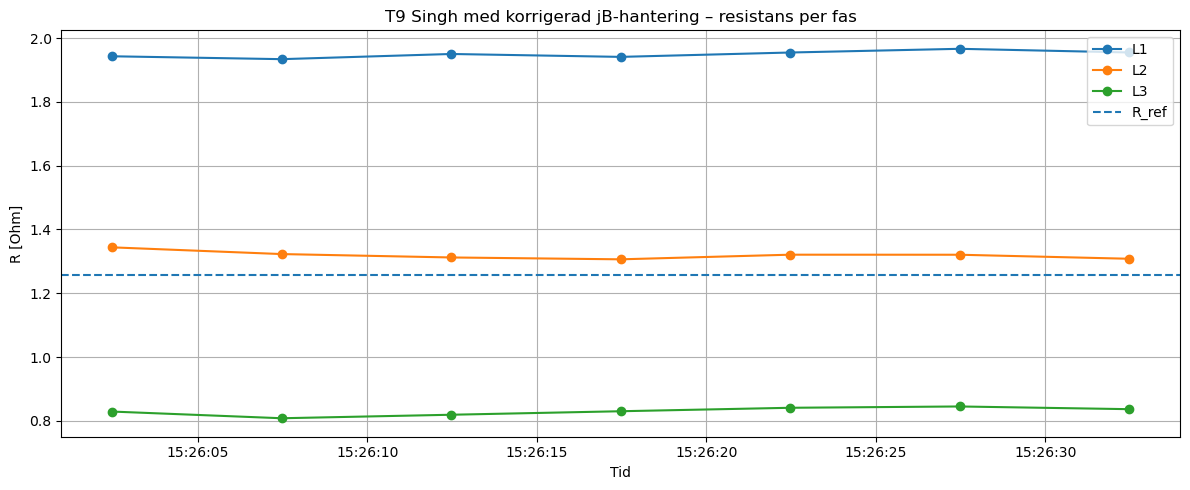

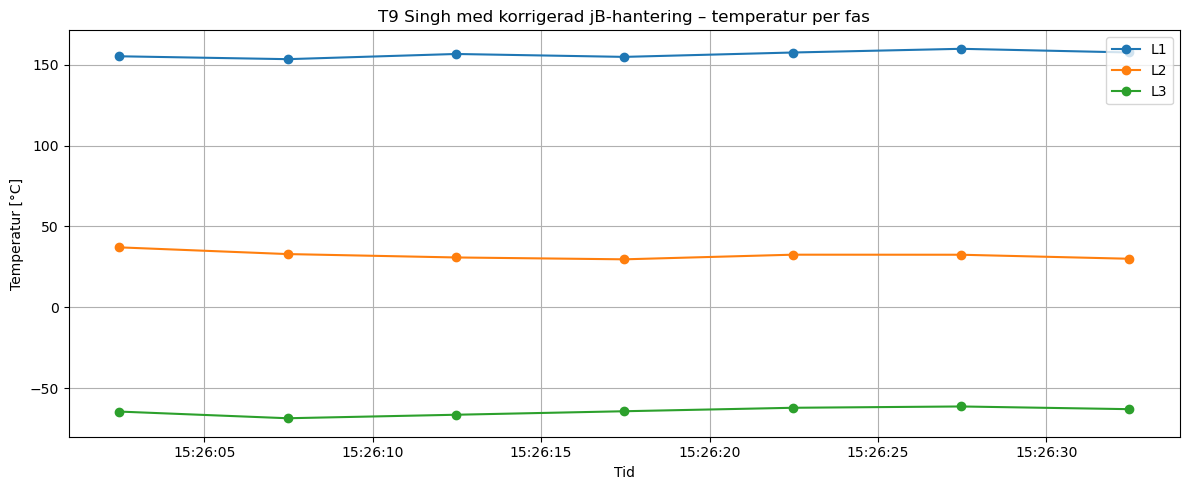

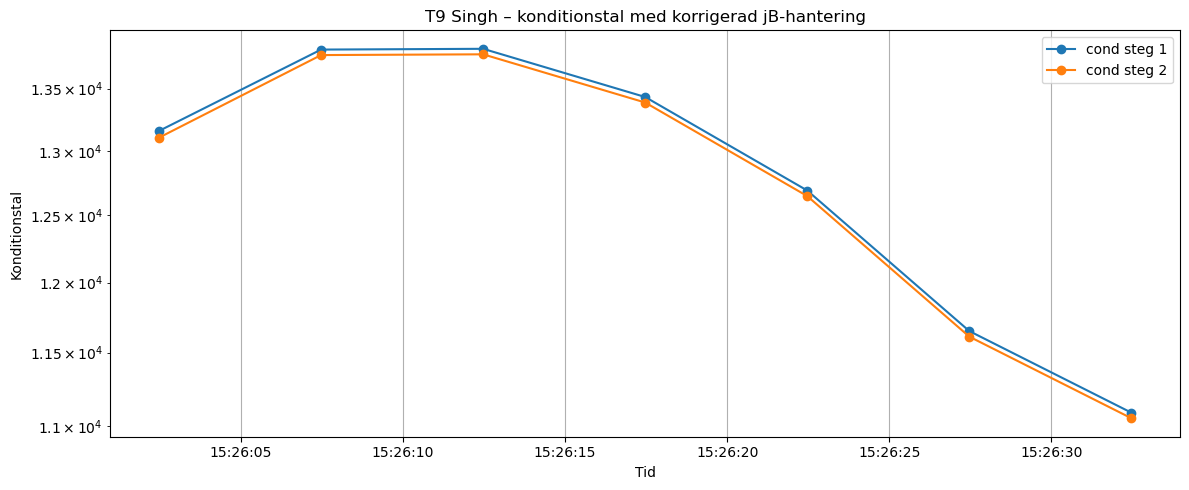

In [5]:

# ============================================================
# KÖR SINGH MED KORRIGERAD jB-HANTERING OCH JÄMFÖR MED GAMMAL
# ============================================================

receiver_phase_map_default = {"L1": "L1", "L2": "L2", "L3": "L3"}
ir_signs_default = {"L1": -1, "L2": -1, "L3": -1}

print("\nKör Singh med korrigerad B-hantering: jB ...")
result_jB, diag_jB = run_singh_variant(
    df_clean,
    receiver_phase_map=receiver_phase_map_default,
    ir_signs=ir_signs_default,
    b_mode="jB",
)

summary_jB, metrics_jB = summarize_singh_result(result_jB, label="corrected_jB")
display(summary_jB.round(6))
display(pd.DataFrame([metrics_jB]).round(6))

print("\nKör Singh med tidigare B-hantering: old ...")
result_old, diag_old = run_singh_variant(
    df_clean,
    receiver_phase_map=receiver_phase_map_default,
    ir_signs=ir_signs_default,
    b_mode="old",
)

summary_old, metrics_old = summarize_singh_result(result_old, label="old_B_handling")
display(summary_old.round(6))
display(pd.DataFrame([metrics_old]).round(6))

summary_jB["Implementation"] = "corrected_jB"
summary_old["Implementation"] = "old_B_handling"
compare_B = pd.concat([summary_jB, summary_old], ignore_index=True)

print("\nJämförelse mellan korrigerad och tidigare B-hantering:")
display(compare_B.round(6))

# Spara huvudresultat
result_jB.to_excel(OUTPUT_DIR / "singh_corrected_jB_long.xlsx", index=False)
diag_jB.to_excel(OUTPUT_DIR / "singh_corrected_jB_diagnostics.xlsx", index=False)
result_old.to_excel(OUTPUT_DIR / "singh_old_B_long.xlsx", index=False)
diag_old.to_excel(OUTPUT_DIR / "singh_old_B_diagnostics.xlsx", index=False)
compare_B.to_excel(OUTPUT_DIR / "compare_B_handling_summary.xlsx", index=False)

# Plotta korrigerad jB
plt.figure(figsize=(12, 5))
for ph in PHASES:
    d = result_jB[result_jB["Phase"] == ph]
    plt.plot(d["Timestamp"], d["R_Ohm"], marker="o", label=ph)
plt.axhline(R_REF, linestyle="--", label="R_ref")
plt.title("T9 Singh med korrigerad jB-hantering – resistans per fas")
plt.xlabel("Tid")
plt.ylabel("R [Ohm]")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "T9_singh_corrected_jB_R_per_phase.png", dpi=200)
plt.show()

plt.figure(figsize=(12, 5))
for ph in PHASES:
    d = result_jB[result_jB["Phase"] == ph]
    plt.plot(d["Timestamp"], d["T_C"], marker="o", label=ph)
plt.title("T9 Singh med korrigerad jB-hantering – temperatur per fas")
plt.xlabel("Tid")
plt.ylabel("Temperatur [°C]")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "T9_singh_corrected_jB_T_per_phase.png", dpi=200)
plt.show()

plt.figure(figsize=(12, 5))
plt.semilogy(diag_jB["Timestamp"], diag_jB["cond_step1"], marker="o", label="cond steg 1")
plt.semilogy(diag_jB["Timestamp"], diag_jB["cond_step2"], marker="o", label="cond steg 2")
plt.title("T9 Singh – konditionstal med korrigerad jB-hantering")
plt.xlabel("Tid")
plt.ylabel("Konditionstal")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "T9_singh_corrected_jB_condition_numbers.png", dpi=200)
plt.show()


In [6]:

# ============================================================
# DIAGNOSTIK 1: FASMAPPNING OCH STRÖMTECKEN MED KORRIGERAD jB
# ============================================================

def test_phase_mapping_and_current_direction(df, quick_windows=QUICK_WINDOWS):
    rows = []

    sign_cases = {
        "Ir_inverted_all": {"L1": -1, "L2": -1, "L3": -1},
        "Ir_raw_all": {"L1": 1, "L2": 1, "L3": 1},
    }

    for perm in itertools.permutations(PHASES):
        receiver_phase_map = dict(zip(PHASES, perm))

        for sign_label, ir_signs in sign_cases.items():
            label = (
                f"L1->{receiver_phase_map['L1']}, "
                f"L2->{receiver_phase_map['L2']}, "
                f"L3->{receiver_phase_map['L3']}, "
                f"{sign_label}"
            )

            result_long, diag = run_singh_variant(
                df,
                receiver_phase_map=receiver_phase_map,
                ir_signs=ir_signs,
                max_windows=quick_windows,
                b_mode="jB",
            )

            summary, metrics = summarize_singh_result(result_long, label=label)

            rows.append({
                "label": label,
                "map_L1": receiver_phase_map["L1"],
                "map_L2": receiver_phase_map["L2"],
                "map_L3": receiver_phase_map["L3"],
                "current_case": sign_label,
                "R_phase_spread_Ohm": metrics.get("R_phase_spread_Ohm", np.nan),
                "R_cv_percent": metrics.get("R_cv_percent", np.nan),
                "R_mean_abs_error_vs_ref": metrics.get("R_mean_abs_error_vs_ref", np.nan),
                "X_mean_abs_error_vs_ref": metrics.get("X_mean_abs_error_vs_ref", np.nan),
                "negative_R_count": metrics.get("negative_R_count", np.nan),
                "score": metrics.get("score", np.nan),
            })

    return pd.DataFrame(rows).sort_values("score")


def test_all_current_sign_combinations(df, receiver_phase_map=None, quick_windows=QUICK_WINDOWS):
    if receiver_phase_map is None:
        receiver_phase_map = {"L1": "L1", "L2": "L2", "L3": "L3"}

    rows = []

    for signs_tuple in itertools.product([-1, 1], repeat=3):
        ir_signs = dict(zip(PHASES, signs_tuple))
        sign_label = "_".join([f"{ph}:{ir_signs[ph]}" for ph in PHASES])

        result_long, diag = run_singh_variant(
            df,
            receiver_phase_map=receiver_phase_map,
            ir_signs=ir_signs,
            max_windows=quick_windows,
            b_mode="jB",
        )

        summary, metrics = summarize_singh_result(result_long, label=sign_label)

        rows.append({
            "signs": sign_label,
            "R_phase_spread_Ohm": metrics.get("R_phase_spread_Ohm", np.nan),
            "R_cv_percent": metrics.get("R_cv_percent", np.nan),
            "R_mean_abs_error_vs_ref": metrics.get("R_mean_abs_error_vs_ref", np.nan),
            "X_mean_abs_error_vs_ref": metrics.get("X_mean_abs_error_vs_ref", np.nan),
            "negative_R_count": metrics.get("negative_R_count", np.nan),
            "score": metrics.get("score", np.nan),
        })

    return pd.DataFrame(rows).sort_values("score")


def phase_pairing_sanity_matrices(df):
    U_angle_mean = pd.DataFrame(index=PHASES, columns=PHASES, dtype=float)
    U_angle_std = pd.DataFrame(index=PHASES, columns=PHASES, dtype=float)

    I_angle_mean_corr = pd.DataFrame(index=PHASES, columns=PHASES, dtype=float)
    I_angle_std_corr = pd.DataFrame(index=PHASES, columns=PHASES, dtype=float)

    U_mag_ratio = pd.DataFrame(index=PHASES, columns=PHASES, dtype=float)
    I_mag_ratio = pd.DataFrame(index=PHASES, columns=PHASES, dtype=float)

    for sph in PHASES:
        for rph in PHASES:
            dU = wrap_angle_deg(df[f"U{sph}ANG_S"] - df[f"U{rph}ANG_R"])

            Ir_ang_corr = wrap_angle_deg(df[f"I{rph}ANG_R"] + 180.0)
            dI = wrap_angle_deg(df[f"I{sph}ANG_S"] - Ir_ang_corr)

            U_angle_mean.loc[sph, rph] = circ_mean_deg(dU)
            U_angle_std.loc[sph, rph] = np.nanstd(dU)

            I_angle_mean_corr.loc[sph, rph] = circ_mean_deg(dI)
            I_angle_std_corr.loc[sph, rph] = np.nanstd(dI)

            U_mag_ratio.loc[sph, rph] = np.nanmean(df[f"U{sph}MAG_S"] / df[f"U{rph}MAG_R"])
            I_mag_ratio.loc[sph, rph] = np.nanmean(df[f"I{sph}MAG_S"] / df[f"I{rph}MAG_R"])

    return {
        "U_angle_mean_deg": U_angle_mean,
        "U_angle_std_deg": U_angle_std,
        "I_angle_mean_corr_deg": I_angle_mean_corr,
        "I_angle_std_corr_deg": I_angle_std_corr,
        "U_mag_ratio": U_mag_ratio,
        "I_mag_ratio": I_mag_ratio,
    }


def signal_variation_table(df):
    rows = []
    for ph in PHASES:
        for station in ["S", "R"]:
            for quantity in ["U", "I"]:
                mag_col = f"{quantity}{ph}MAG_{station}"
                ang_col = f"{quantity}{ph}ANG_{station}"

                mag_mean = df[mag_col].mean()
                mag_std = df[mag_col].std()
                mag_cv_pct = 100.0 * mag_std / abs(mag_mean)

                ang_std = np.nanstd(wrap_angle_deg(df[ang_col] - circ_mean_deg(df[ang_col])))

                rows.append({
                    "Phase": ph,
                    "Station": station,
                    "Quantity": quantity,
                    "Magnitude_mean": mag_mean,
                    "Magnitude_std": mag_std,
                    "Magnitude_CV_percent": mag_cv_pct,
                    "Angle_std_deg": ang_std,
                })

    return pd.DataFrame(rows)


print("\nKör fasmappningsdiagnostik med korrigerad jB...")
phase_mapping_test = test_phase_mapping_and_current_direction(df_clean, quick_windows=QUICK_WINDOWS)
display(phase_mapping_test.head(12).round(6))

best = phase_mapping_test.iloc[0]
best_receiver_phase_map = {
    "L1": best["map_L1"],
    "L2": best["map_L2"],
    "L3": best["map_L3"],
}

best_ir_signs_global = {"L1": -1, "L2": -1, "L3": -1} if best["current_case"] == "Ir_inverted_all" else {"L1": 1, "L2": 1, "L3": 1}

print("Bästa fasmappning:", best_receiver_phase_map)
print("Bästa globala strömtecken:", best["current_case"])

print("\nKör per-fas strömteckentest...")
current_sign_test = test_all_current_sign_combinations(
    df_clean,
    receiver_phase_map=best_receiver_phase_map,
    quick_windows=QUICK_WINDOWS,
)
display(current_sign_test.round(6))

best_sign_row = current_sign_test.iloc[0]
best_ir_signs = {}
for item in best_sign_row["signs"].split("_"):
    ph, sign = item.split(":")
    best_ir_signs[ph] = int(sign)

print("Bästa per-fas strömtecken:", best_ir_signs)

print("\nFasparningsmatriser:")
sanity = phase_pairing_sanity_matrices(df_clean)
for name, table in sanity.items():
    print("\n", name)
    display(table.round(6))

variation_stats = signal_variation_table(df_clean)
print("\nSignalvariation:")
display(variation_stats.round(6))

phase_mapping_test.to_excel(OUTPUT_DIR / "T9_phase_mapping_test_corrected_jB.xlsx", index=False)
current_sign_test.to_excel(OUTPUT_DIR / "T9_current_sign_test_corrected_jB.xlsx", index=False)
variation_stats.to_excel(OUTPUT_DIR / "T9_signal_variation_stats.xlsx", index=False)

with pd.ExcelWriter(OUTPUT_DIR / "T9_phase_pairing_sanity_matrices.xlsx", engine="openpyxl") as writer:
    for name, table in sanity.items():
        table.to_excel(writer, sheet_name=name[:31])



Kör fasmappningsdiagnostik med korrigerad jB...


,label,map_L1,map_L2,map_L3,current_case,R_phase_spread_Ohm,R_cv_percent,R_mean_abs_error_vs_ref,X_mean_abs_error_vs_ref,negative_R_count,score
0,"L1->L1, L2->L2, L3->L3, Ir_inverted_all",L1,L2,L3,Ir_inverted_all,1.119980,33.568625,0.398644,0.312679,0,1.518625
8,"L1->L3, L2->L1, L3->L2, Ir_inverted_all",L3,L1,L2,Ir_inverted_all,0.761902,6.974878,3.451592,10.870801,0,4.213493
7,"L1->L2, L2->L3, L3->L1, Ir_raw_all",L2,L3,L1,Ir_raw_all,0.407458,2.837253,4.815265,4.627598,0,5.222723
4,"L1->L2, L2->L1, L3->L3, Ir_inverted_all",L2,L1,L3,Ir_inverted_all,10.460667,2485.818489,3.633186,6.630186,2,214.093853
2,"L1->L1, L2->L3, L3->L2, Ir_inverted_all",L1,L3,L2,Ir_inverted_all,10.710998,41526.298619,3.797363,6.451890,2,214.508360
10,"L1->L3, L2->L2, L3->L1, Ir_inverted_all",L3,L2,L1,Ir_inverted_all,11.173904,2845.172123,3.749952,6.583806,2,214.923856
5,"L1->L2, L2->L1, L3->L3, Ir_raw_all",L2,L1,L3,Ir_raw_all,10.460667,2485.818489,4.178926,6.479814,4,414.639593
3,"L1->L1, L2->L3, L3->L2, Ir_raw_all",L1,L3,L2,Ir_raw_all,10.710998,41526.298607,4.635696,6.658110,4,415.346694
11,"L1->L3, L2->L2, L3->L1, Ir_raw_all",L3,L2,L1,Ir_raw_all,11.173904,2845.172123,4.588285,6.526194,4,415.762189
1,"L1->L1, L2->L2, L3->L3, Ir_raw_all",L1,L2,L3,Ir_raw_all,1.119980,33.568625,2.621051,12.797321,6,603.741031


Bästa fasmappning: {'L1': 'L1', 'L2': 'L2', 'L3': 'L3'}
Bästa globala strömtecken: Ir_inverted_all

Kör per-fas strömteckentest...


,signs,R_phase_spread_Ohm,R_cv_percent,R_mean_abs_error_vs_ref,X_mean_abs_error_vs_ref,negative_R_count,score
0,L1:-1_L2:-1_L3:-1,1.119980,33.568625,0.398644,0.312679,0,1.518625
1,L1:-1_L2:-1_L3:1,2.757199,144.679167,0.944384,4.550392,2,203.701583
2,L1:-1_L2:1_L3:-1,3.272042,286.099173,1.236978,4.296261,2,204.509020
4,L1:1_L2:-1_L3:-1,3.272042,2018.855828,1.236978,4.576026,2,204.509020
6,L1:1_L2:1_L3:-1,2.757199,144.679167,2.075311,8.559608,4,404.832510
3,L1:-1_L2:1_L3:1,3.272042,2018.855828,1.782717,8.533974,4,405.054760
5,L1:1_L2:-1_L3:1,3.272042,286.099173,1.782717,8.813739,4,405.054760
7,L1:1_L2:1_L3:1,1.119980,33.568625,2.621051,12.797321,6,603.741031


Bästa per-fas strömtecken: {'L1': -1, 'L2': -1, 'L3': -1}

Fasparningsmatriser:

 U_angle_mean_deg


...

,L1,L2,L3
L1,1.004807,1.004045,1.002436
L2,1.004702,1.003941,1.002331
L3,1.005393,1.004631,1.003021



 I_mag_ratio


,L1,L2,L3
L1,1.009345,0.957008,1.003758
L2,1.064777,1.009561,1.058879
L3,1.017181,0.964435,1.011547



Signalvariation:


,Phase,Station,Quantity,Magnitude_mean,Magnitude_std,Magnitude_CV_percent,Angle_std_deg
0,L1,S,U,80881.832154,59.313727,0.073334,79.416219
1,L1,S,I,191.488386,7.256400,3.789473,79.281753
2,L1,R,U,80494.933192,59.876751,0.074386,79.423817
3,L1,R,I,189.716944,7.223517,3.807524,79.276723
4,L2,S,U,80873.427367,55.289879,0.068366,79.415789
5,L2,S,I,201.993311,7.365628,3.646471,79.286845
6,L2,R,U,80555.973495,55.207615,0.068533,79.422720
7,L2,R,I,200.081669,7.327747,3.662378,79.262137
8,L3,S,U,80929.066089,58.534579,0.072328,79.415442
9,L3,S,I,192.969070,7.163958,3.712490,79.266956



Kör extra vinkeltester med korrigerad jB...
Kör vr_only_phase
Kör ir_only_phase
Kör station_common_phase
Kör local_vi_phase
Kör station_common_all
Kör ir_only_all


,Mode,Affected_phase,Offset_deg,Result_phase,R_mean_Ohm,R_std_Ohm,X_mean_Ohm,X_std_Ohm,T_mean_C,T_std_C,R_phase_spread_Ohm
0,vr_only_phase,L1,-1.0,L1,1.938590,0.006393,6.395020,0.030325,154.397528,1.261462,1.11998
1,vr_only_phase,L1,-1.0,L2,1.333453,0.014897,5.975374,0.040886,34.987523,2.939518,1.11998
2,vr_only_phase,L1,-1.0,L3,0.818609,0.014822,6.356570,0.033104,-66.605090,2.924822,1.11998
3,vr_only_phase,L1,-0.5,L1,1.938590,0.006393,6.395020,0.030325,154.397528,1.261462,1.11998
4,vr_only_phase,L1,-0.5,L2,1.333453,0.014897,5.975374,0.040886,34.987523,2.939518,1.11998
5,vr_only_phase,L1,-0.5,L3,0.818609,0.014822,6.356570,0.033104,-66.605090,2.924822,1.11998
6,vr_only_phase,L1,-0.2,L1,1.938590,0.006393,6.395020,0.030325,154.397528,1.261462,1.11998
7,vr_only_phase,L1,-0.2,L2,1.333453,0.014897,5.975374,0.040886,34.987523,2.939518,1.11998
8,vr_only_phase,L1,-0.2,L3,0.818609,0.014822,6.356570,0.033104,-66.605090,2.924822,1.11998
9,vr_only_phase,L1,-0.1,L1,1.938590,0.006393,6.395020,0.030325,154.397528,1.261462,1.11998


,Mode,Affected_phase,Result_phase,Offset_minus_deg,Offset_plus_deg,dR_ddeg_Ohm_per_deg,dX_ddeg_Ohm_per_deg,dT_ddeg_C_per_deg,abs_dT_ddeg_C_per_deg
0,ir_only_all,ALL,L1,-0.1,0.1,0.111614,-0.033835,22.024498,22.024498
1,ir_only_all,ALL,L2,-0.1,0.1,0.104290,-0.023273,20.579233,20.579233
2,ir_only_all,ALL,L3,-0.1,0.1,0.110943,-0.014287,21.892074,21.892074
3,ir_only_phase,L1,L1,-0.1,0.1,0.111614,-0.033835,22.024498,22.024498
4,ir_only_phase,L1,L2,-0.1,0.1,0.000000,-0.000000,0.000000,0.000000
5,ir_only_phase,L1,L3,-0.1,0.1,0.000000,-0.000000,0.000000,0.000000
6,ir_only_phase,L2,L1,-0.1,0.1,0.000000,0.000000,0.000000,0.000000
7,ir_only_phase,L2,L2,-0.1,0.1,0.104290,-0.023273,20.579233,20.579233
8,ir_only_phase,L2,L3,-0.1,0.1,0.000000,0.000000,0.000000,0.000000
9,ir_only_phase,L3,L1,-0.1,0.1,-0.000000,-0.000000,-0.000000,0.000000


,Mode,Affected_phase,Result_phase,Offset_minus_deg,Offset_plus_deg,dR_ddeg_Ohm_per_deg,dX_ddeg_Ohm_per_deg,dT_ddeg_C_per_deg,abs_dT_ddeg_C_per_deg
7,station_common_all,ALL,L1,-0.1,0.1,0.111614,-0.033835,22.024498,22.024498
1,ir_only_phase,L1,L1,-0.1,0.1,0.111614,-0.033835,22.024498,22.024498
0,ir_only_all,ALL,L1,-0.1,0.1,0.111614,-0.033835,22.024498,22.024498
8,station_common_phase,L1,L1,-0.1,0.1,0.111614,-0.033835,22.024498,22.024498
10,station_common_phase,L3,L3,-0.1,0.1,0.110943,-0.014287,21.892074,21.892074
3,ir_only_phase,L3,L3,-0.1,0.1,0.110943,-0.014287,21.892074,21.892074
9,station_common_phase,L2,L2,-0.1,0.1,0.104290,-0.023273,20.579233,20.579233
2,ir_only_phase,L2,L2,-0.1,0.1,0.104290,-0.023273,20.579233,20.579233
4,local_vi_phase,L1,L1,-0.1,0.1,-0.055807,0.016917,-11.012253,11.012253
6,local_vi_phase,L3,L3,-0.1,0.1,-0.055472,0.007144,-10.946041,10.946041


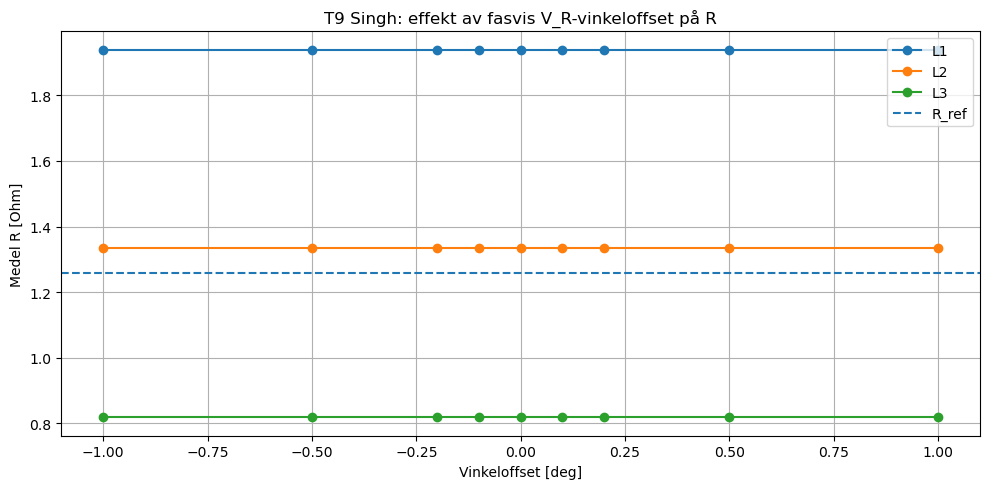

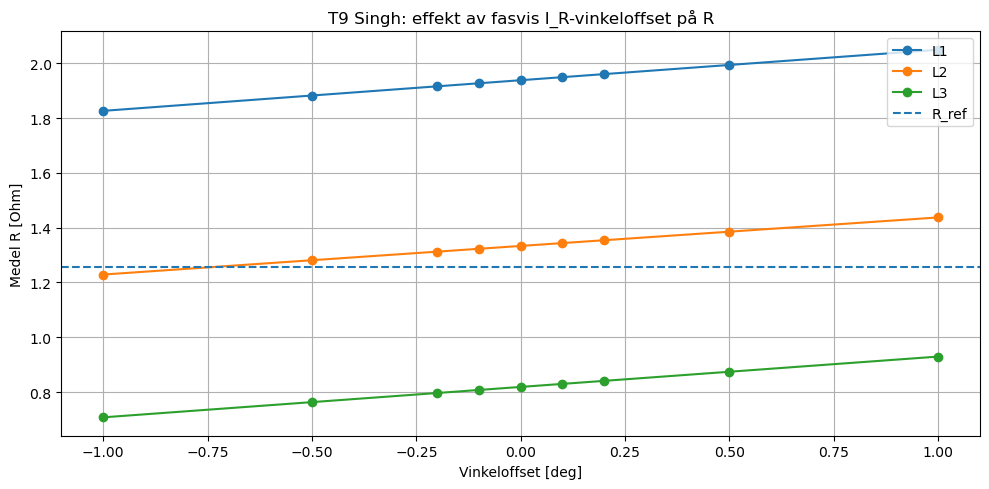

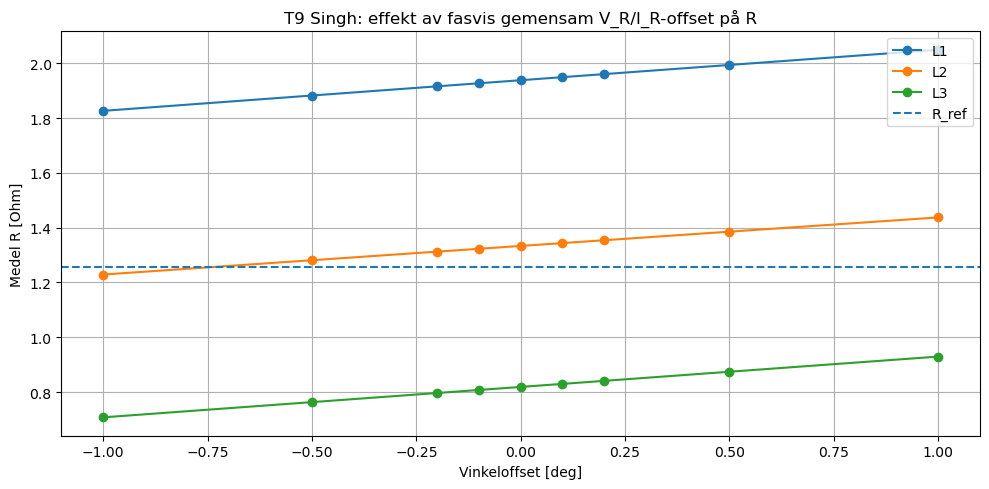

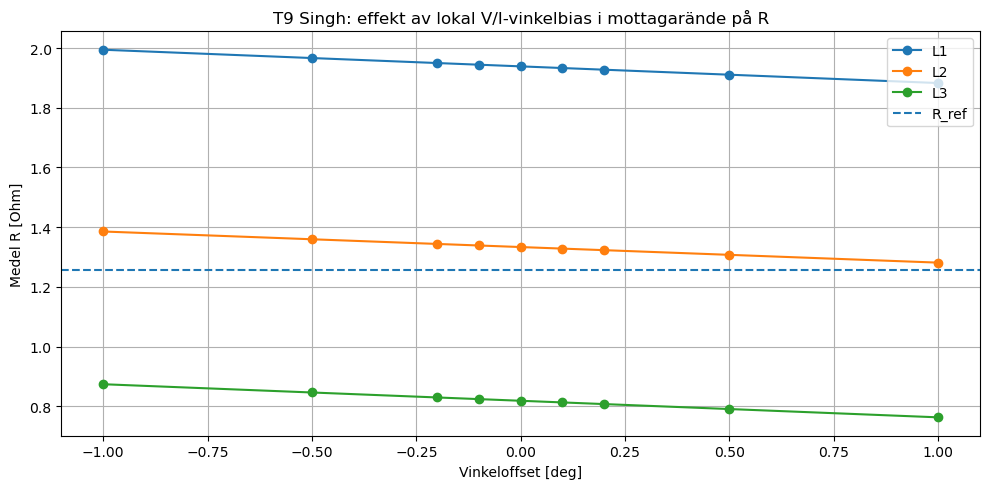

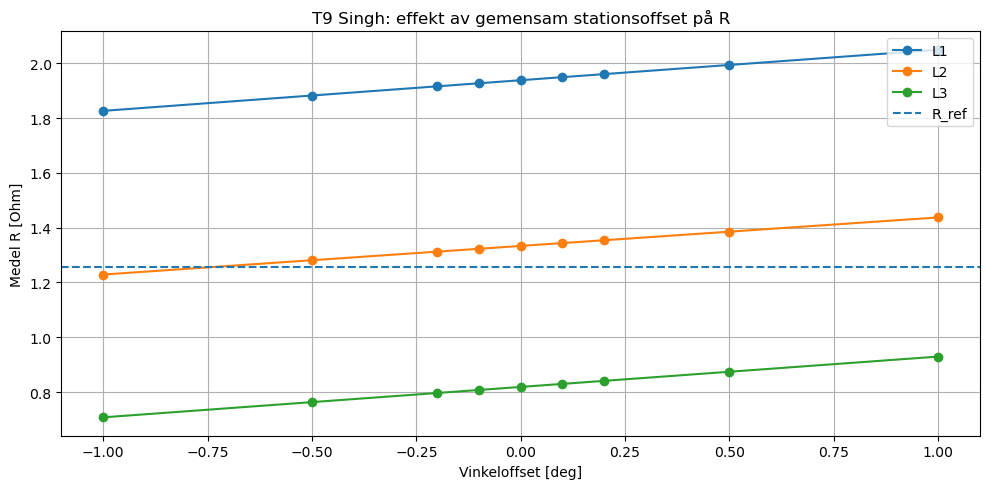

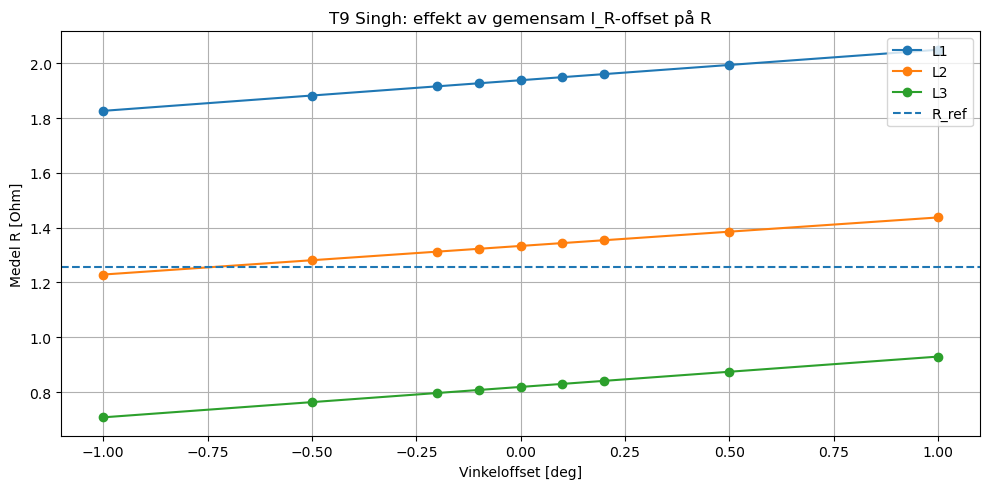


Klar med T9.
Huvudresultat: C:\Users\lundi\OneDrive\Skóli\Svíþjóð\Exjobb\Arbetet\Källor\phasor_dlr-main\phasor_dlr-main\data\T9_Singh_corrected_B_diagnostics
Extra vinkeltester: C:\Users\lundi\OneDrive\Skóli\Svíþjóð\Exjobb\Arbetet\Källor\phasor_dlr-main\phasor_dlr-main\data\T9_Singh_corrected_B_diagnostics\extra_angle_diagnostics_corrected_jB


In [7]:

# ============================================================
# DIAGNOSTIK 2: VINKELTESTER MED KORRIGERAD jB
# ============================================================

EXTRA_DIR = OUTPUT_DIR / "extra_angle_diagnostics_corrected_jB"
EXTRA_DIR.mkdir(parents=True, exist_ok=True)

OFFSETS_DEG = np.array([-1.0, -0.5, -0.2, -0.1, 0.0, 0.1, 0.2, 0.5, 1.0])
QUICK_WINDOWS_EXTRA = 2

def run_offset_case(mode, offset_deg, affected_phase="ALL"):
    """
    mode:
      vr_only_phase          : V_R i en fas roteras
      ir_only_phase          : I_R i en fas roteras
      station_common_phase   : V_R och I_R i en fas roteras tillsammans
      local_vi_phase         : V_R +offset/2 och I_R -offset/2 i en fas
      station_common_all     : alla V_R och I_R roteras tillsammans
      ir_only_all            : alla I_R roteras tillsammans
    """

    vr_offsets = {ph: 0.0 for ph in PHASES}
    ir_offsets = {ph: 0.0 for ph in PHASES}

    if mode == "vr_only_phase":
        vr_offsets[affected_phase] = offset_deg

    elif mode == "ir_only_phase":
        ir_offsets[affected_phase] = offset_deg

    elif mode == "station_common_phase":
        vr_offsets[affected_phase] = offset_deg
        ir_offsets[affected_phase] = offset_deg

    elif mode == "local_vi_phase":
        vr_offsets[affected_phase] = offset_deg / 2.0
        ir_offsets[affected_phase] = -offset_deg / 2.0

    elif mode == "station_common_all":
        vr_offsets = {ph: offset_deg for ph in PHASES}
        ir_offsets = {ph: offset_deg for ph in PHASES}

    elif mode == "ir_only_all":
        ir_offsets = {ph: offset_deg for ph in PHASES}

    else:
        raise ValueError(f"Okänt mode: {mode}")

    result_long, diag = run_singh_variant(
        df_clean,
        receiver_phase_map=best_receiver_phase_map,
        ir_signs=best_ir_signs,
        vr_angle_offsets=vr_offsets,
        ir_angle_offsets=ir_offsets,
        max_windows=QUICK_WINDOWS_EXTRA,
        b_mode="jB",
    )

    summary = (
        result_long
        .groupby("Phase")
        .agg(
            R_mean_Ohm=("R_Ohm", "mean"),
            R_std_Ohm=("R_Ohm", "std"),
            X_mean_Ohm=("X_Ohm", "mean"),
            X_std_Ohm=("X_Ohm", "std"),
            T_mean_C=("T_C", "mean"),
            T_std_C=("T_C", "std"),
        )
        .reset_index()
    )

    rows = []
    r_spread = summary["R_mean_Ohm"].max() - summary["R_mean_Ohm"].min()

    for _, row in summary.iterrows():
        rows.append({
            "Mode": mode,
            "Affected_phase": affected_phase,
            "Offset_deg": offset_deg,
            "Result_phase": row["Phase"],
            "R_mean_Ohm": row["R_mean_Ohm"],
            "R_std_Ohm": row["R_std_Ohm"],
            "X_mean_Ohm": row["X_mean_Ohm"],
            "X_std_Ohm": row["X_std_Ohm"],
            "T_mean_C": row["T_mean_C"],
            "T_std_C": row["T_std_C"],
            "R_phase_spread_Ohm": r_spread,
        })

    return rows


def run_extended_angle_diagnostics():
    all_rows = []

    phase_modes = [
        "vr_only_phase",
        "ir_only_phase",
        "station_common_phase",
        "local_vi_phase",
    ]

    all_phase_modes = [
        "station_common_all",
        "ir_only_all",
    ]

    for mode in phase_modes:
        print("Kör", mode)
        for affected_phase in PHASES:
            for off in OFFSETS_DEG:
                all_rows.extend(run_offset_case(mode, float(off), affected_phase))

    for mode in all_phase_modes:
        print("Kör", mode)
        for off in OFFSETS_DEG:
            all_rows.extend(run_offset_case(mode, float(off), "ALL"))

    return pd.DataFrame(all_rows)


def calculate_central_slopes(results):
    slope_rows = []
    group_cols = ["Mode", "Affected_phase", "Result_phase"]

    for keys, g in results.groupby(group_cols):
        mode, affected_phase, result_phase = keys
        g = g.sort_values("Offset_deg").copy()

        g_neg = g[g["Offset_deg"] < 0]
        g_pos = g[g["Offset_deg"] > 0]

        if g_neg.empty or g_pos.empty:
            continue

        neg_row = g_neg.iloc[(g_neg["Offset_deg"].abs()).argmin()]
        pos_row = g_pos.iloc[(g_pos["Offset_deg"].abs()).argmin()]

        dx = pos_row["Offset_deg"] - neg_row["Offset_deg"]
        if dx == 0:
            continue

        slope_rows.append({
            "Mode": mode,
            "Affected_phase": affected_phase,
            "Result_phase": result_phase,
            "Offset_minus_deg": neg_row["Offset_deg"],
            "Offset_plus_deg": pos_row["Offset_deg"],
            "dR_ddeg_Ohm_per_deg": (pos_row["R_mean_Ohm"] - neg_row["R_mean_Ohm"]) / dx,
            "dX_ddeg_Ohm_per_deg": (pos_row["X_mean_Ohm"] - neg_row["X_mean_Ohm"]) / dx,
            "dT_ddeg_C_per_deg": (pos_row["T_mean_C"] - neg_row["T_mean_C"]) / dx,
        })

    slopes = pd.DataFrame(slope_rows)
    if slopes.empty:
        return slopes, pd.DataFrame()

    slopes["abs_dT_ddeg_C_per_deg"] = slopes["dT_ddeg_C_per_deg"].abs()

    max_slopes = (
        slopes
        .sort_values("abs_dT_ddeg_C_per_deg", ascending=False)
        .groupby(["Mode", "Affected_phase"])
        .first()
        .reset_index()
        .sort_values("abs_dT_ddeg_C_per_deg", ascending=False)
    )

    return slopes, max_slopes


def plot_phase_mode_same_phase(results, mode, title, filename):
    d = results[
        (results["Mode"] == mode)
        & (results["Affected_phase"] != "ALL")
        & (results["Affected_phase"] == results["Result_phase"])
    ].copy()

    plt.figure(figsize=(10, 5))
    for ph in PHASES:
        dd = d[d["Affected_phase"] == ph]
        plt.plot(dd["Offset_deg"], dd["R_mean_Ohm"], marker="o", label=ph)
    plt.axhline(R_REF, linestyle="--", label="R_ref")
    plt.title(title)
    plt.xlabel("Vinkeloffset [deg]")
    plt.ylabel("Medel R [Ohm]")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.savefig(EXTRA_DIR / filename, dpi=200)
    plt.show()


def plot_all_phase_mode(results, mode, title, filename):
    d = results[
        (results["Mode"] == mode)
        & (results["Affected_phase"] == "ALL")
    ].copy()

    plt.figure(figsize=(10, 5))
    for ph in PHASES:
        dd = d[d["Result_phase"] == ph]
        plt.plot(dd["Offset_deg"], dd["R_mean_Ohm"], marker="o", label=ph)
    plt.axhline(R_REF, linestyle="--", label="R_ref")
    plt.title(title)
    plt.xlabel("Vinkeloffset [deg]")
    plt.ylabel("Medel R [Ohm]")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.savefig(EXTRA_DIR / filename, dpi=200)
    plt.show()


print("\nKör extra vinkeltester med korrigerad jB...")
extended_angle_results = run_extended_angle_diagnostics()
angle_slopes, angle_max_slopes = calculate_central_slopes(extended_angle_results)

display(extended_angle_results.head(30).round(6))
display(angle_slopes.head(30).round(6))
display(angle_max_slopes.round(6))

plot_phase_mode_same_phase(
    extended_angle_results,
    "vr_only_phase",
    "T9 Singh: effekt av fasvis V_R-vinkeloffset på R",
    "T9_singh_vr_only_phase_offset_R.png",
)

plot_phase_mode_same_phase(
    extended_angle_results,
    "ir_only_phase",
    "T9 Singh: effekt av fasvis I_R-vinkeloffset på R",
    "T9_singh_ir_only_phase_offset_R.png",
)

plot_phase_mode_same_phase(
    extended_angle_results,
    "station_common_phase",
    "T9 Singh: effekt av fasvis gemensam V_R/I_R-offset på R",
    "T9_singh_station_common_phase_offset_R.png",
)

plot_phase_mode_same_phase(
    extended_angle_results,
    "local_vi_phase",
    "T9 Singh: effekt av lokal V/I-vinkelbias i mottagarände på R",
    "T9_singh_local_vi_phase_offset_R.png",
)

plot_all_phase_mode(
    extended_angle_results,
    "station_common_all",
    "T9 Singh: effekt av gemensam stationsoffset på R",
    "T9_singh_station_common_all_offset_R.png",
)

plot_all_phase_mode(
    extended_angle_results,
    "ir_only_all",
    "T9 Singh: effekt av gemensam I_R-offset på R",
    "T9_singh_ir_only_all_offset_R.png",
)

extended_angle_results.to_excel(EXTRA_DIR / "T9_extended_angle_results.xlsx", index=False)
angle_slopes.to_excel(EXTRA_DIR / "T9_extended_angle_slopes.xlsx", index=False)
angle_max_slopes.to_excel(EXTRA_DIR / "T9_extended_angle_max_slopes.xlsx", index=False)

with pd.ExcelWriter(EXTRA_DIR / "T9_extended_angle_diagnostics.xlsx", engine="openpyxl") as writer:
    extended_angle_results.to_excel(writer, sheet_name="results", index=False)
    angle_slopes.to_excel(writer, sheet_name="central_slopes", index=False)
    angle_max_slopes.to_excel(writer, sheet_name="max_slopes", index=False)

print("\nKlar med T9.")
print("Huvudresultat:", OUTPUT_DIR.resolve())
print("Extra vinkeltester:", EXTRA_DIR.resolve())


In [8]:

# ============================================================
# SKAPA EN KORT TOLKNINGSTABELL FÖR RAPPORTEN
# ============================================================

# Bästa fasmappning och strömtecken
best_phase_mapping_row = phase_mapping_test.iloc[0]
best_current_sign_row = current_sign_test.iloc[0]

# Sammanfattning från korrigerad jB
summary_report = summary_jB.copy()

# Konditionstal
condition_summary = diag_jB[["cond_step1", "cond_step2"]].describe().T.reset_index()
condition_summary = condition_summary.rename(columns={"index": "Condition_number"})

# Diagnostiktabell
diagnostic_report_rows = [
    {
        "Kontroll": "Fasmappning",
        "Resultat": f"L1->{best_phase_mapping_row['map_L1']}, L2->{best_phase_mapping_row['map_L2']}, L3->{best_phase_mapping_row['map_L3']}",
        "Tolkning": "Normal diagonal fasmappning var bästa testade variant.",
    },
    {
        "Kontroll": "Mottagarström",
        "Resultat": best_current_sign_row["signs"],
        "Tolkning": "180° korrigering av mottagarström stöds av diagnostiken.",
    },
    {
        "Kontroll": "B-hantering",
        "Resultat": "jB används i steg 1 och steg 2",
        "Tolkning": "Shuntsusceptansen behandlas som imaginär admittans.",
    },
    {
        "Kontroll": "Konditionstal",
        "Resultat": f"Steg 1 max {diag_jB['cond_step1'].max():.2e}, steg 2 max {diag_jB['cond_step2'].max():.2e}",
        "Tolkning": "Lösningen är möjlig men känslig för systematiska mätfel.",
    },
]

diagnostic_report = pd.DataFrame(diagnostic_report_rows)

print("Diagnostiktabell för rapport:")
display(diagnostic_report)

print("Sammanfattning R/T per fas med korrigerad jB:")
display(summary_report.round(6))

print("Konditionstal:")
display(condition_summary.round(6))

with pd.ExcelWriter(OUTPUT_DIR / "T9_report_tables.xlsx", engine="openpyxl") as writer:
    diagnostic_report.to_excel(writer, sheet_name="diagnostic_summary", index=False)
    summary_report.to_excel(writer, sheet_name="R_T_summary_corrected_jB", index=False)
    condition_summary.to_excel(writer, sheet_name="condition_summary", index=False)
    compare_B.to_excel(writer, sheet_name="compare_B_handling", index=False)
    angle_max_slopes.to_excel(writer, sheet_name="angle_max_slopes", index=False)

print("Rapporttabeller sparade till:", OUTPUT_DIR / "T9_report_tables.xlsx")


Diagnostiktabell för rapport:


,Kontroll,Resultat,Tolkning
0,Fasmappning,"L1->L1, L2->L2, L3->L3",Normal diagonal fasmappning var bästa testade ...
1,Mottagarström,L1:-1_L2:-1_L3:-1,180° korrigering av mottagarström stöds av dia...
2,B-hantering,jB används i steg 1 och steg 2,Shuntsusceptansen behandlas som imaginär admit...
3,Konditionstal,"Steg 1 max 1.38e+04, steg 2 max 1.38e+04",Lösningen är möjlig men känslig för systematis...


Sammanfattning R/T per fas med korrigerad jB:


,Phase,R_mean_Ohm,R_std_Ohm,R_min_Ohm,R_max_Ohm,X_mean_Ohm,X_std_Ohm,T_mean_C,T_std_C,T_min_C,T_max_C,Implementation
0,L1,1.949321,0.010791,1.934069,1.966544,6.389782,0.025055,156.515033,2.129312,153.505540,159.913578,corrected_jB
1,L2,1.319383,0.012678,1.306457,1.343986,5.974170,0.024563,32.211200,2.501690,29.660596,37.066075,corrected_jB
2,L3,0.829868,0.012835,0.808128,0.845079,6.350205,0.021549,-64.383505,2.532769,-68.673251,-61.381977,corrected_jB


Konditionstal:


,Condition_number,count,mean,std,min,25%,50%,75%,max
0,cond_step1,7.0,12810.055521,1071.905624,11088.253620,12170.488091,13157.150745,13627.105134,13829.797834
1,cond_step2,7.0,12765.700299,1068.014325,11050.847873,12129.370505,13103.580735,13581.585213,13783.562050


Rapporttabeller sparade till: C:\Users\lundi\OneDrive\Skóli\Svíþjóð\Exjobb\Arbetet\Källor\phasor_dlr-main\phasor_dlr-main\data\T9_Singh_corrected_B_diagnostics\T9_report_tables.xlsx
